# 12 - Error Analysis on the True-Hate Class

Dr Hunter, 1 September: *"look at the ones that it gets right and the ones it gets wrong,
focusing on true hates... at the very least, look at a decent number of examples. It might
even be feasible to look at the whole lot."*

Every model in this study does badly on the hate class. Hunter could not explain it and said
plainly that he cannot read the data: *"I don't speak [Hinglish]... maybe you can read that
better than I could."*

**So the code below does the mechanical half. The reading is yours, and it is the part of this
project nobody else can do.**

There are 332 true-hate posts in the frozen test set. That is small enough to read all of
them. Section 6 exports them for exactly that.

### 1. Setup

In [4]:
try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e: print('local / already mounted:', e)

import sys; sys.path.insert(0, '/content/drive/MyDrive/dissertation/notebooks')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

from hinglish_hate import load_lexicon, script_profile, clean_text
from hinglish_hate.baseline import build_full_pipeline

pd.set_option('display.max_colwidth', 140)
DATA = Path('/content/drive/MyDrive/dissertation/data')
W    = Path('/content/drive/MyDrive/dissertation/writing'); W.mkdir(parents=True, exist_ok=True)
FIG  = W/'figures'; FIG.mkdir(exist_ok=True)

train_df = pd.read_parquet(DATA/'splits'/'bohra_train.parquet')
test_df  = pd.read_parquet(DATA/'splits'/'bohra_test.parquet')
terms    = load_lexicon(DATA/'hinglish_slur_lexicon.csv')
print(f'train {len(train_df)} | test {len(test_df)} | lexicon {len(terms)} surface forms')

Mounted at /content/drive
train 3659 | test 915 | lexicon 1219 surface forms


### 2. Label sanity check

Hunter noticed two confusion matrices looked like mirror images and asked whether labels might
be flipped: *"it might be worth checking you haven't misindexed anything."*

Ten minutes to answer with evidence rather than assumption. Bohra et al. (2018) report roughly
36% hate. If the measured rate matches, the mapping through `_to_binary` is almost certainly
correct.

In [5]:
print(f"train hate rate : {train_df['label'].mean():.3f}")
print(f"test  hate rate : {test_df['label'].mean():.3f}")
print(f"published (Bohra et al. 2018): ~0.363")
print()
print('label==1 examples (should read as hate/offensive):')
for t in test_df[test_df['label']==1]['text'].head(3): print('   ', str(t)[:110])
print('\nlabel==0 examples (should read as NOT hate):')
for t in test_df[test_df['label']==0]['text'].head(3): print('   ', str(t)[:110])
print('\nRead these yourself. If they are the wrong way round, everything downstream is wrong.')

train hate rate : 0.363
test  hate rate : 0.363
published (Bohra et al. 2018): ~0.363

label==1 examples (should read as hate/offensive):
    Aap September  2017 meh chal yeah report ing aajtak aur zee news ki udhar mass murderer kiya Gaye Hindu Ka aur
    I hate these muslim molvis n hindu babas jo dusro ki khushiyon Ko daba ke khud itne maje lete he chupke.
    Han be Rapist Muhammad ke follower.madarchod paegambar Muhammad ne 6 sal. Ki ladki ka rape Kiya Tha...or wo ch

label==0 examples (should read as NOT hate):
    Abe rape pirit aurat ke bacche haram khor kutte ke bille suvar
    @NimraSohail06 hate humari larki tu Batman hai
    Kon sa pyaar ap dekhana chahte Ho hamen,95000 ko Shaheed Kar k, rape Kar k Kashmir ko graveyard mai tabdeel Ka

Read these yourself. If they are the wrong way round, everything downstream is wrong.


### 3. Fit the baseline and split the hate class into right and wrong

The statistical baseline is used here because it is the strongest model on the hate class and
the fastest to refit. Repeat with a transformer's saved predictions once the pattern is clear.

In [6]:
pipe = build_full_pipeline(terms)
pipe.fit(train_df['text'], train_df['label'])
pred  = pipe.predict(test_df['text'])
proba = pipe.predict_proba(test_df['text'])[:, 1]

res = test_df.copy()
res['pred'] = pred
res['p_hate'] = proba
res['correct'] = res['label'] == res['pred']

cm = confusion_matrix(res['label'], res['pred'])
print('confusion matrix [rows=true, cols=pred]:\n', cm)
print()
print(classification_report(res['label'], res['pred'], target_names=['not','hate'], digits=3))

hate = res[res['label']==1]
caught, missed = hate[hate['correct']], hate[~hate['correct']]
print(f'\nTRUE HATE: {len(hate)} posts | caught {len(caught)} | MISSED {len(missed)}')

confusion matrix [rows=true, cols=pred]:
 [[415 168]
 [140 192]]

              precision    recall  f1-score   support

         not      0.748     0.712     0.729       583
        hate      0.533     0.578     0.555       332

    accuracy                          0.663       915
   macro avg      0.641     0.645     0.642       915
weighted avg      0.670     0.663     0.666       915


TRUE HATE: 332 posts | caught 192 | MISSED 140


### 4. Automatic diagnostics

Before reading anything, check whether the misses differ measurably from the catches. If one
of these separates them cleanly, that is the explanation and it can be quantified.

In [7]:
term_set = set(t.lower() for t in terms)
def lex_hits(t):
    return sum(1 for w in clean_text(str(t)).split() if w in term_set)

for d in (caught, missed):
    d['n_words']    = d['text'].apply(lambda t: len(str(t).split()))
    d['n_chars']    = d['text'].apply(lambda t: len(str(t)))
    d['lex_hits']   = d['text'].apply(lex_hits)
    d['script']     = d['text'].apply(script_profile)
    d['has_at']     = d['text'].str.contains('@', na=False)
    d['has_hash']   = d['text'].str.contains('#', na=False)
    d['has_url']    = d['text'].str.contains('http', na=False)

rows = []
for name, d in [('CAUGHT', caught), ('MISSED', missed)]:
    rows.append({'group':name, 'n':len(d),
                 'mean_words':round(d['n_words'].mean(),1),
                 'mean_chars':round(d['n_chars'].mean(),1),
                 'mean_lexicon_hits':round(d['lex_hits'].mean(),2),
                 'pct_zero_lexicon':round(100*(d['lex_hits']==0).mean(),1),
                 'pct_mention':round(100*d['has_at'].mean(),1),
                 'pct_hashtag':round(100*d['has_hash'].mean(),1),
                 'pct_url':round(100*d['has_url'].mean(),1),
                 'mean_p_hate':round(d['p_hate'].mean(),3)})
diag = pd.DataFrame(rows)
display(diag)
diag.to_csv(W/'error_analysis_diagnostics.csv', index=False)

print('\nThe row to watch is pct_zero_lexicon. If missed posts contain no lexicon term while')
print('caught posts do, the model is relying on the lexicon and the misses are hate expressed')
print('without recognisable slurs - implicit hate, sarcasm, or terms not yet in the lexicon.')

/tmp/ipykernel_2834/430499984.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['n_words']    = d['text'].apply(lambda t: len(str(t).split()))
/tmp/ipykernel_2834/430499984.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['n_chars']    = d['text'].apply(lambda t: len(str(t)))
/tmp/ipykernel_2834/430499984.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

,group,n,mean_words,mean_chars,mean_lexicon_hits,pct_zero_lexicon,pct_mention,pct_hashtag,pct_url,mean_p_hate
0,CAUGHT,192,22.9,123.4,1.65,1.0,14.1,9.4,5.7,0.669
1,MISSED,140,19.5,103.4,1.06,12.1,10.7,1.4,7.9,0.365



The row to watch is pct_zero_lexicon. If missed posts contain no lexicon term while
caught posts do, the model is relying on the lexicon and the misses are hate expressed
without recognisable slurs - implicit hate, sarcasm, or terms not yet in the lexicon.


### 5. Confidence distribution

Is the model *wrong* on the misses, or merely *uncertain*? A cluster near 0.5 means the
decision threshold is the problem and could be tuned. A cluster near 0 means the model is
confidently wrong, which is a much deeper failure.

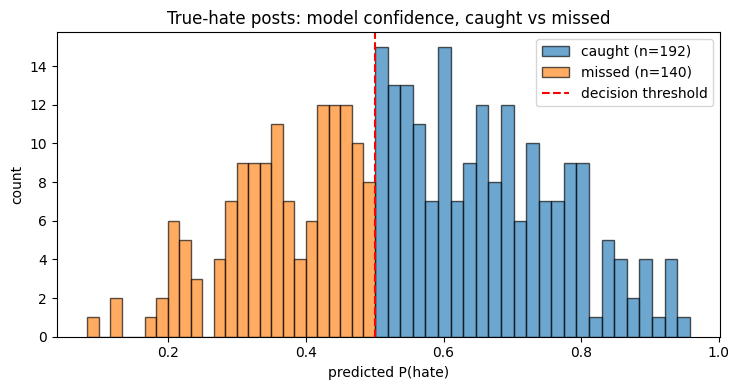

82/140 missed posts scored between 0.35 and 0.50 - near-misses
7/140 scored below 0.20 - confidently wrong


In [8]:
fig, ax = plt.subplots(figsize=(7.5,4))
ax.hist(caught['p_hate'], bins=25, alpha=.65, label=f'caught (n={len(caught)})', edgecolor='black')
ax.hist(missed['p_hate'], bins=25, alpha=.65, label=f'missed (n={len(missed)})', edgecolor='black')
ax.axvline(0.5, color='red', ls='--', lw=1.5, label='decision threshold')
ax.set_xlabel('predicted P(hate)'); ax.set_ylabel('count'); ax.legend()
ax.set_title('True-hate posts: model confidence, caught vs missed')
plt.tight_layout(); plt.savefig(FIG/'fig4_hate_confidence.png', dpi=150, bbox_inches='tight'); plt.show()

near = ((missed['p_hate'] > 0.35) & (missed['p_hate'] < 0.5)).sum()
print(f'{near}/{len(missed)} missed posts scored between 0.35 and 0.50 - near-misses')
print(f'{(missed["p_hate"] < 0.2).sum()}/{len(missed)} scored below 0.20 - confidently wrong')

### 6. Export for manual reading — the part that is yours

All 332 true-hate posts, sorted so the most confident errors come first. Read them.

**What to look for, and write down as you go:**

- Is the hate **implicit**? Sarcasm, dog-whistles, coded references with no slur present
- Are there **slurs missing from the lexicon**? Add them to `MY_TERMS` in notebook 04
- Is it **targeted at a group** in a way that needs world knowledge (caste, religion, region)?
- Would **you** have labelled it hate? Some may simply be mislabelled in the source data
- Is it **too short** to carry signal? Two or three words with no context
- Does it depend on **Devanagari-origin words** that romanise unusually?

Five to ten observations in your own words is what Hunter asked for. It goes on slide 6.

In [9]:
export = pd.concat([
    missed.assign(outcome='MISSED'),
    caught.assign(outcome='caught'),
])[['outcome','p_hate','n_words','lex_hits','script','text']]
export = export.sort_values(['outcome','p_hate'])
export.insert(0, 'my_note', '')          # <- write your observations in this column

out = W/'true_hate_for_reading.csv'
export.to_csv(out, index=False)
print(f'exported {len(export)} posts -> {out}')
print('Open it in Google Sheets and fill in my_note as you read.\n')

print('='*78)
print('THE 15 MOST CONFIDENT MISSES  (model was surest these were NOT hate)')
print('='*78)
for _, r in missed.nsmallest(15, 'p_hate').iterrows():
    print(f"p={r['p_hate']:.3f} lex={r['lex_hits']} | {str(r['text'])[:150]}")

exported 332 posts -> /content/drive/MyDrive/dissertation/writing/true_hate_for_reading.csv
Open it in Google Sheets and fill in my_note as you read.

THE 15 MOST CONFIDENT MISSES  (model was surest these were NOT hate)
p=0.082 lex=1 | Islea Rape hote hai
p=0.122 lex=0 | Bal Thakray muslims k against jo kar rahay, usko kia bolain ge? https://twitter.com/chintskap/status/875447907922567170 …
p=0.130 lex=1 | ab v to rape band nahi ho raha hai
p=0.173 lex=1 | tujhe murder kar dungi main!
p=0.190 lex=1 | Abhi terrorism aur baqi hai mere dost @chintskappic.twitter.com/T4V5ejyywa
p=0.192 lex=1 | Sir hum piche isiliye hai ki desh ka kanoon sahi nahi hai har 26m me ek rape hota hai bharat me daily koi javan saheed hota h border par sir
p=0.199 lex=1 | history main likha jayega...11 logon ne 120 crore ka rape kiya..vo b aik sath
p=0.204 lex=1 | CM thai to terrorism sai kasai ladna hai sab malum tha. PM hotai hi sab bhool gayai. Or cake kaha nai pakistan bhi chala gayai
p=0.208 lex=0 | Army ko r

In [10]:
print('='*78)
print('15 CAUGHT, for contrast (model was surest these WERE hate)')
print('='*78)
for _, r in caught.nlargest(15, 'p_hate').iterrows():
    print(f"p={r['p_hate']:.3f} lex={r['lex_hits']} | {str(r['text'])[:150]}")

15 CAUGHT, for contrast (model was surest these WERE hate)
p=0.958 lex=1 | i hate sarrdi
p=0.937 lex=1 | I hate padhai..
p=0.936 lex=2 | Chutiya he is. I hate him.
p=0.927 lex=1 | i hate Dhanapur
p=0.924 lex=5 | I hate hate hate hate this filthy woman lopamudra..koi bhi angle se lagta nahi India ko representkihai @lopa9999 @TeamBaniJ @RealVinduSingh
p=0.919 lex=1 | I hate this "ngalusa mina" nonsense. Inobuphuma silwe phakathi nje.
p=0.899 lex=1 | Rajneeti ko gandhwa diya ha in sapa Congress ne I hate this type of rajneeti
p=0.899 lex=3 | Karachi ko support karnay wali bachiyan bhi ugly hen, i hate this yaar. nonsense
p=0.895 lex=4 | ...I hate Gaddar Indian Behuda Mulla-These Molwi-Muslimo ko Gandi & Barbaad Soch de rhe h..ye Islam ke Dusmn=Islam ko Kbr me Dalege-Aamin https://twit
p=0.887 lex=3 | Mera jawab un shilpa hatters ko hai k sunobe sale kamino tum jake kahni marjao...apna kutta giri mat dikhao.Shilpians @ShindeShilpaS k liye mar mittne
p=0.881 lex=3 | Tumhe israeli kutte ke s

### 7. False positives

The other error direction, which Hunter also asked about: *"not hate that's identified as hate
and hate that's not being identified as hate."*

These matter for the ethics argument. A false positive is ordinary speech being silenced.

In [11]:
fp = res[(res['label']==0) & (res['pred']==1)]
print(f'{len(fp)} false positives\n')
for _, r in fp.nlargest(12, 'p_hate').iterrows():
    print(f"p={r['p_hate']:.3f} | {str(r['text'])[:150]}")
fp[['p_hate','text']].to_csv(W/'false_positives_for_reading.csv', index=False)
print(f'\nexported -> false_positives_for_reading.csv')

168 false positives

p=0.949 | Rape and woman persecution ke khilaf awaz toh uthate hi hai iska matlab yeh nahi Kisi aur ke khilaf awaz na uthae, waise bata du film ka virodh bhi ra
p=0.938 | wai sadenli yu hate mi ameera
p=0.928 | Aur koi bolo Mauka mauka.pandya atleast faught jadeja ko maut aa jaye.hate this game hate it
p=0.921 | yaar ye heena Ro Ko Bula rahi hai lekin awaz se Poori dunia Ke Kaan Band krwa rahi hai Kaisi Pagal hai yaar ye I hate Her Bhot jyada Gandi Gali aa rah
p=0.855 | kina raakhyaa? Hate brigade le raastra baadi bhanera hate failaaulaa
p=0.848 | I hate this word ek waqt tha jab mai is word ko sunne ke liye trash rahi thi but ab ghin aati hai is word se
p=0.830 | Abe rape pirit aurat ke bacche haram khor kutte ke bille suvar
p=0.827 | Uska land juhsleh sala suwar ka awlaad.. yeh harami logoh neh tera maa behen ko chodaa taa.. tum sab ko yeh goreh log rape kiya taa.. salaaa
p=0.808 | BJP  se nafrat,Modi se nafrat thik hai.Lekin apni BJP/Modi se nafrat ko desh se na

### 8. Write your findings here

Replace the placeholders with what you actually observed. This cell becomes slide 6 and a
paragraph of the dissertation. **Do not skip it** - the automatic diagnostics above cannot
substitute for reading the text.

1.
2.
3.
4.
5.

**Any new slur terms found:** add them to `MY_TERMS` in notebook 04, re-run the lexicon build,
then re-run the baseline. If hate-F1 improves, that improvement is directly attributable to
your native-speaker knowledge - and that is a measurable contribution, not a claimed one.